In [16]:
import sys, os
import torch
import random
from PIL import Image
import numpy as np
from munch import munchify
PROJECT_ROOT = "/data/online_lang_splatting"
sys.path.insert(0, PROJECT_ROOT)
from gaussian_splatting.scene.gaussian_model import GaussianModel
from gaussian_splatting.gaussian_renderer import render
from gaussian_splatting.utils.graphics_utils import getProjectionMatrix2, getWorld2View2
from utils.camera_utils import Camera
from utils.dataset import load_dataset
from utils.config_utils import load_config

In [2]:

config_path = "/data/online_lang_splatting/configs/rgbd/replicav2/room0.yaml"
config = load_config(config_path)


pipeline_params = munchify(config["pipeline_params"])
model_params = munchify(config["model_params"])

In [3]:
plymap_path = "./output/room_0/omni_data_result/room_0/2026-05-07-10-05-19/point_cloud/final/point_cloud-2.ply"
gaussian = GaussianModel(sh_degree=0, config={"language": {"language_train": True}})
gaussian.load_ply(plymap_path)


GaussianModel: Loaded 119206 points from ./output/room_0/omni_data_result/room_0/2026-05-07-10-05-19/point_cloud/final/point_cloud-2.ply


In [4]:

dataset = load_dataset(model_params, model_params.source_path, config=config)
projection_matrix = getProjectionMatrix2(
    znear=0.01,
    zfar=100.0,
    fx=dataset.fx,
    fy=dataset.fy,
    
    cx=dataset.cx,
    cy=dataset.cy,
    W=dataset.width,
    H=dataset.height,
).transpose(0, 1)
projection_matrix = projection_matrix.to(device="cuda")
len(dataset)

In load poses 2
Using v2 parser


2000

In [10]:
viewpoint_stack = []
for i in random.sample(range(len(dataset)), 20):
    pass

vs = Camera.init_from_dataset(dataset, 0, projection_matrix)
vs.T = vs.T_gt
vs.R = vs.R_gt
viewpoint_stack.append(vs)



(680, 1200, 3) (680, 1200)


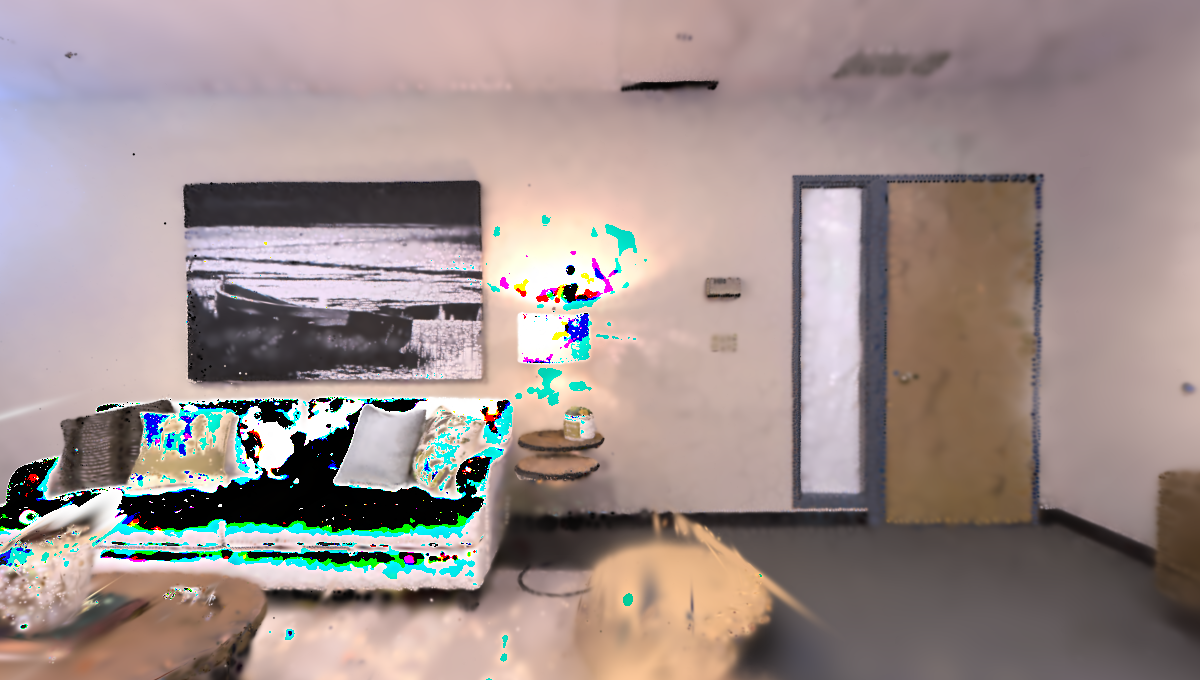

In [48]:
T = torch.eye(4, device="cuda",dtype=torch.float64)
T[0,0]=-1
T[1,1]=-1
T[2,2]=1
T[3,3]=1

T[3,0:3] = torch.tensor([-0.0, 0.0, -1.0], device="cuda", dtype=torch.float64)

viewpoint_stack[0].T = T[3,0:3]
viewpoint_stack[0].R = T[0:3,0:3]

bg_color = [0, 0, 0]
background = torch.tensor(bg_color, dtype=torch.float32, device="cuda")
view_point = viewpoint_stack[0]
render_pkg = render(view_point, gaussian, pipeline_params,background)
(image, depth, language, viewspace_points, visibility_filter, radii, opacity, n_touched)  =  (render_pkg["render"],
                render_pkg["depth"],
                render_pkg["language"],
                render_pkg["viewspace_points"],
                render_pkg["visibility_filter"],
                render_pkg["radii"],
                render_pkg["opacity"],
                render_pkg["n_touched"])


image_ = image.permute(1,2,0).cpu().detach().squeeze().squeeze().numpy() *  255
depth_ = depth.cpu().detach().numpy() *  255
image_ = image_.astype(np.uint8), 
depth_ = depth_.astype(np.uint8)
print(image_[0].shape, depth_[0].shape)
img = Image.fromarray(image_[0])
img
    


In [8]:
# import cv2
# bg_color = [0, 0, 0]
# background = torch.tensor(bg_color, dtype=torch.float32, device="cuda")
# for view_point in viewpoint_stack:
    
# # view_point = viewpoint_stack[0]
#     print(view_point.uid)
#     render_pkg = render(view_point, gaussian, pipeline_params,background)
#     (image, 
#     depth, 
#     language, 
#     viewspace_points, 
#     visibility_filter, 
#     radii, 
#     opacity, 
#     n_touched)  =  (render_pkg["render"],
#                     render_pkg["depth"],
#                     render_pkg["language"],
#                     render_pkg["viewspace_points"],
#                     render_pkg["visibility_filter"],
#                     render_pkg["radii"],
#                     render_pkg["opacity"],
#                     render_pkg["n_touched"])

#     from PIL import Image
#     import numpy as np
#     image_ = image.permute(1,2,0).cpu().detach().squeeze().squeeze().numpy() *  255
#     depth_ = depth.cpu().detach().numpy() *  255
#     image_ = image_.astype(np.uint8), 
#     depth_ = depth_.astype(np.uint8)
#     print(image_[0].shape, depth_[0].shape)
#     # img = Image.fromarray(image_[0])
#     # dpt = Image.fromarray(depth_[0])
#     cv2.imshow("Live Map", image_[0])

# # Wait 1ms so the window updates; 'q' to quit
#     if cv2.waitKey(1) & 0xFF == ord('q'):
#         cv2.destroyAllWindows()
#         break
